In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
video_path = "./videos/RL1.mp4"
cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print(f"fps={fps}, frames={frame_count}, size={width}x{height}, duration={frame_count/fps:.1f}s")

fps=60.000654583052075, frames=31043, size=3840x2160, duration=517.4s


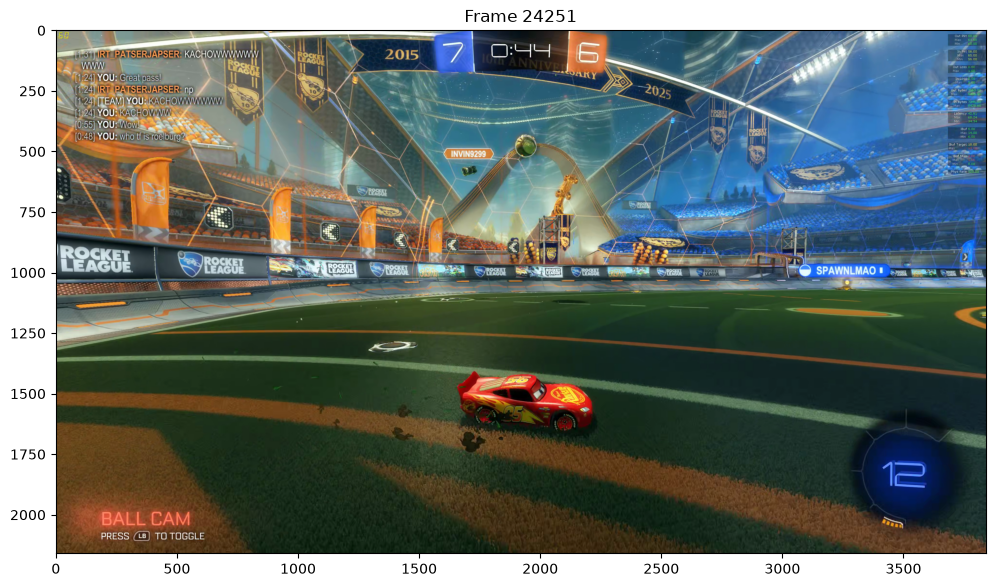

In [3]:
middle_frame_idx = frame_count // 2 + 8730

cap.set(cv2.CAP_PROP_POS_FRAMES, middle_frame_idx)
ret, frame = cap.read()

if not ret:
    raise RuntimeError("Failed to read frame")

# OpenCV loads as BGR, matplotlib wants RGB
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 7))
plt.imshow(frame_rgb)
plt.title(f"Frame {middle_frame_idx}")
plt.axis("on")  # keep axes on so you can read pixel coordinates
plt.show()

In [4]:
cv2.imwrite("middle_frame.png", frame)
print("Saved middle_frame.png")

Saved middle_frame.png


In [5]:
crop_roi = (int(width*0.5), int(height*0.033), int(width*0.221), int(height*0.22))      # placeholder

x1, y1, x2, y2 = crop_roi
crop_region = frame[y1:y2, x1:x2]

plt.figure(figsize=(6, 4))
plt.imshow(cv2.cvtColor(crop_region, cv2.COLOR_BGR2RGB))
plt.title("Crop ROI")
plt.show()

error: OpenCV(5.0.0) /Users/xperience/GHA-OpenCV-Python/_work/opencv-python/opencv-python/opencv/modules/imgproc/src/color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'


<Figure size 600x400 with 0 Axes>

In [6]:
from crop import crop_portrait, crop_portrait_better


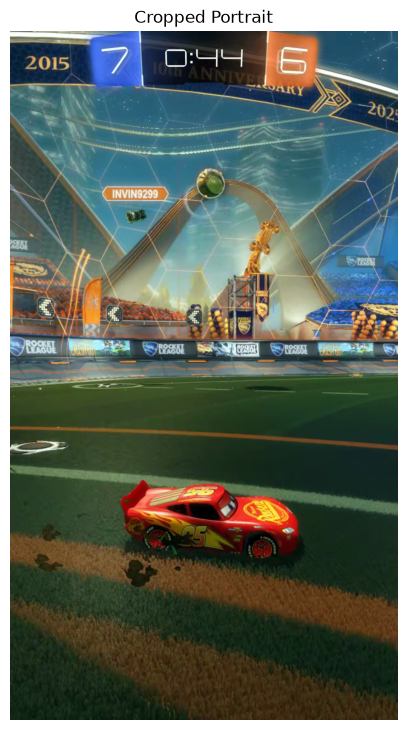

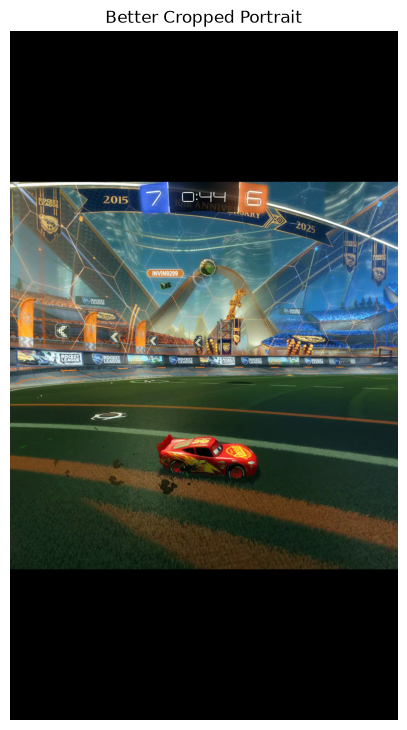

In [7]:
portrait = crop_portrait(frame)
portrait_better = crop_portrait_better(frame, wider_ratio=1)

# Display the cropped portrait
plt.figure(figsize=(5, 9))
plt.imshow(cv2.cvtColor(portrait, cv2.COLOR_BGR2RGB))
plt.title("Cropped Portrait")
plt.axis("off")
plt.show()

# Display the better cropped portrait
plt.figure(figsize=(5, 9))
plt.imshow(cv2.cvtColor(portrait_better, cv2.COLOR_BGR2RGB))
plt.title("Better Cropped Portrait")
plt.axis("off")
plt.show()

In [8]:
# save better cropped portrait
cv2.imwrite("portrait_better.png", portrait_better)

True